In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import pathlib
import numpy as np
import torch
import torch.nn as nn
from torchsummary import summary
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from torch.nn import functional as F
from common.args import Args
from data import transforms as T
from fastmri.data import transforms as T1
from model import Model
import scipy.io as sio
from fastmri.data import subsample
from torch.optim import RMSprop
from torch.optim.lr_scheduler import StepLR
from common.subsample import create_mask_for_mask_type
import fastmri
import math
import h5py
from data.mri_data import SliceData
from torch.utils.data import DataLoader
from models.unet_model import UnetModel
from loss_function.utils_gradlossUpdated import Gradient_Loss
from fastmri.losses import SSIMLoss
from pytorch_lightning.callbacks import LearningRateMonitor, DeviceStatsMonitor
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from common import evaluate
from dclayer.dclayer import updated_DClayer

In [2]:
class DataTransform:
    """
    Data Transformer for training U-Net models.
    """

    def __init__(self, resolution, which_challenge, mask_func=None, use_seed=True):
        """
        Args:
            mask_func (common.subsample.MaskFunc): A function that can create a mask of
                appropriate shape.
            resolution (int): Resolution of the image.
            which_challenge (str): Either "singlecoil" or "multicoil" denoting the dataset.
            use_seed (bool): If true, this class computes a pseudo random number generator seed
                from the filename. This ensures that the same mask is used for all the slices of
                a given volume every time.
        """
        if which_challenge not in ('singlecoil', 'multicoil'):
            raise ValueError(f'Challenge should either be "singlecoil" or "multicoil"')
        self.mask_func = mask_func
        self.resolution = resolution
        self.which_challenge = which_challenge
        self.use_seed = use_seed

    def __call__(self, kspace, target, attrs, fname, slice): #
        # if self.which_challenge == 'multicoil':
        #     image = fastmri.rss(target)
        image = T.to_tensor(target.astype(complex))
        k_space = T.fft2c_new(image)
        
        # Apply mask
        seed = None if not self.use_seed else tuple(map(ord, fname))
        masked_kspace, mask,_ = T1.apply_mask(k_space, self.mask_func, seed)
        inv_mask = (1 - mask)
        "Add noise"
        # tau = 0.0042
        # masked_kspace = masked_kspace + (torch.randn(masked_kspace.shape)) / math.sqrt(2) * tau
        zf = T.ifft2c_new(masked_kspace)
        dirty = T.complex_abs(zf).type(torch.FloatTensor)

        target = T.to_tensor(target.astype(np.float32))

        return dirty, target, fname, slice,masked_kspace,inv_mask

In [3]:
def create_data_loaders(train_data_paths, val_data_path, mask_func, batch_size, resolution, challenge, sample_rate):
    if challenge not in ('singlecoil', 'multicoil'):
        raise ValueError(f"Challenge should be either 'singlecoil' or 'multicoil', got {challenge}")

    train_datasets = [
        SliceData(
            root=path,
            transform=DataTransform(resolution, challenge, mask_func, use_seed=True),
            challenge=challenge,
            sample_rate=sample_rate,
        )
        for path in train_data_paths
    ]
    train_dataset = torch.utils.data.ConcatDataset(train_datasets)

    val_dataset = SliceData(
        root=val_data_path,
        transform=DataTransform(resolution, challenge, mask_func, use_seed=True),
        challenge=challenge,
        sample_rate=sample_rate,
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    return train_loader, val_loader


In [3]:
from matplotlib import pyplot as plt
def show_slices(data, slice_nums, cmap=None): # visualisation
    fig = plt.figure(figsize=(8,8))
    for i, num in enumerate(slice_nums):
        plt.subplot(1, len(slice_nums), i + 1)
        plt.imshow(data[num], cmap=cmap)
        plt.axis('off')

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Paths and Data Loader
train_data_paths = [
    "/home/susant/Knee_Multicoil_train_batch0/multicoil_train",
    "/home/susant/Knee_Multicoil_train_batch1/multicoil_train"
]
val_data_path = "/storage/FastMRI/Knee/knee_multicoil_val_subset"
mask_func = subsample.RandomMaskFunc(center_fractions=[0.08], accelerations=[4])
train_loader, val_loader = create_data_loaders(train_data_paths, val_data_path, mask_func, 
                                               batch_size=1, resolution=320, challenge='multicoil', sample_rate=1.0)

Text(0.5, 1.0, 'Target Image')

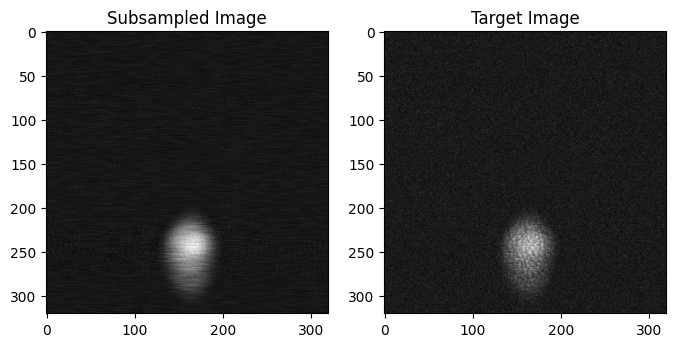

In [143]:
# Visualization code (for a single batch of training data)
batch = next(iter(val_loader))
dirty, target, _, _, masked_kspace, inv_mask = batch

images_np = dirty.squeeze().cpu().numpy()
targets_np = target.squeeze().cpu().numpy()

fig = plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.imshow(images_np, cmap='gray')
plt.title('Subsampled Image')
plt.subplot(1,2,2)
plt.imshow(targets_np, cmap='gray')
plt.title('Target Image')

In [ ]:
# Unet_Model
class Unet_Model(nn.Module):
    def __init__(self,num_chans, num_pools, drop_prob):
        super().__init__()

        self.in_chans = num_chans
        self.num_pools = num_pools
        self.drop_prob = drop_prob

        self.unet = UnetModel(in_chans=1, 
                              out_chans=1, 
                              chans=num_chans, 
                              num_pool_layers=num_pools, 
                              drop_prob=drop_prob)
        
        self.unet_model = UnetModel(in_chans=5, 
                                    out_chans=1, 
                                    chans=num_chans, 
                                    num_pool_layers=num_pools, 
                                    drop_prob=drop_prob).cuda()

    def forward(self, input):
        output = self.unet(input.unsqueeze(1)).squeeze(1)
        output = torch.add(input, output)
        return output
    
    def last_layer(self, input):
        output = self.unet_model(input).squeeze(1)
        return output

    def updatedcascad(self, input, mean, std, masked_kspace, inv_mask):
        unet1 = self.forward(input)
        outUDC1, int_output1 = updated_DClayer(unet1, masked_kspace, inv_mask, mean, std)

        unet2 = self.forward(outUDC1)
        outUDC2, int_output2 = updated_DClayer(unet2, masked_kspace, inv_mask, mean, std)

        unet3 = self.forward(outUDC2)
        outUDC3, int_output3 = updated_DClayer(unet3, masked_kspace, inv_mask, mean, std)

        unet4 = self.forward(outUDC3)
        outUDC4, int_output4 = updated_DClayer(unet4, masked_kspace, inv_mask, mean, std)

        concat = torch.cat([outUDC4.unsqueeze(1), int_output1.unsqueeze(1),
                            int_output2.unsqueeze(1), int_output3.unsqueeze(1),
                            int_output4.unsqueeze(1)], 1)

        unet5 = self.last_layer(concat)
        output = torch.add(outUDC4, unet5)
        outUDC5, _ = updated_DClayer(output, masked_kspace,loss = F.l1_loss(output, target.to(device)) inv_mask, mean, std)
        return outUDC5

In [ ]:
import torch
import torch.nn as nn
from ptflops import get_model_complexity_info
import re

# Assume this is your original model
class Unet_Model(nn.Module):
    def __init__(self, num_chans, num_pools, drop_prob):
        super().__init__()
        self.unet = UnetModel(in_chans=1, out_chans=1, chans=num_chans, num_pool_layers=num_pools, drop_prob=drop_prob)
        self.unet_model = UnetModel(in_chans=5, out_chans=1, chans=num_chans, num_pool_layers=num_pools, drop_prob=drop_prob)

    def forward_step(self, input):
        output = self.unet(input.unsqueeze(1)).squeeze(1)
        return input + output

    def last_layer(self, input):
        return self.unet_model(input).squeeze(1)

    def updatedcascad(self, input, mean, std, masked_kspace, inv_mask):
        unet1 = self.forward_step(input)
        outUDC1, int_output1 = updated_DClayer(unet1, masked_kspace, inv_mask, mean, std)

        unet2 = self.forward_step(outUDC1)
        outUDC2, int_output2 = updated_DClayer(unet2, masked_kspace, inv_mask, mean, std)

        unet3 = self.forward_step(outUDC2)
        outUDC3, int_output3 = updated_DClayer(unet3, masked_kspace, inv_mask, mean, std)

        unet4 = self.forward_step(outUDC3)
        outUDC4, int_output4 = updated_DClayer(unet4, masked_kspace, inv_mask, mean, std)

        concat = torch.cat([
            outUDC4.unsqueeze(1), int_output1.unsqueeze(1),
            int_output2.unsqueeze(1), int_output3.unsqueeze(1),
            int_output4.unsqueeze(1)
        ], dim=1)

        unet5 = self.last_layer(concat)
        output = outUDC4 + unet5
        outUDC5, _ = updated_DClayer(output, masked_kspace, inv_mask, mean, std)
        return outUDC5

# Wrapper to inject dummy data into FLOPs estimator
class WrappedForFlops(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        # Create dummy k-space & mask tensors with same shape
        # Proper shape: (B, 2, H, W)
        b, h, w = x.shape
        masked_kspace = torch.randn(b, h, w, 2, device=x.device)
        inv_mask = torch.ones(b, h, w, 1, device=x.device)
        mean = torch.tensor([0.0], device=x.device)
        std = torch.tensor([1.0], device=x.device)
        return self.model.updatedcascad(x, mean, std, masked_kspace, inv_mask)

# Instantiate and profile
device = 'cuda'
original_model = Unet_Model(num_chans=32, num_pools=4, drop_prob=0.0).to(device)
wrapped = WrappedForFlops(original_model).to(device)

with torch.cuda.device(0):
    macs, params = get_model_complexity_info(wrapped, (320, 320), as_strings=True, print_per_layer_stat=False)
    print(f"MACs: {macs}")
    print(f"Params: {params}")
    print(f"Estimated GFLOPs: {macs} (1 MAC ≈ 2 FLOPs)")
    
    # Extract the numerical value
    flops = eval(re.findall(r'([\d.]+)', macs)[0])*2
    # Extract the unit
    flops_unit = re.findall(r'([A-Za-z]+)', macs)[0][0]
    print('Computational complexity: {} {}Flops'.format(flops, flops_unit))


In [ ]:
if __name__ == "__main__":
    # Create a random input image
    image = torch.rand((1, 320, 320))  # Shape: (Batch, H, W)
    image = image.unsqueeze(1)  # Add channel dimension: (1, 1, 320, 320)

    # Instantiate the model
    model = Unet_Model(num_chans = 32, num_pools = 4, drop_prob=0.0)
    print("Model output shape:", model(image).shape)  # Forward pass test

# Get a batch from the validation loader
batch = next(iter(val_loader))
dirty, target, _, _, masked_kspace, inv_mask = batch

# Normalize data
dirty, mean, std = T.normalize_instance(dirty, eps=1e-11)
target = T.normalize(target, mean, std, eps=1e-11)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Transfer model and data to device
model = model.to(device)
dirty, masked_kspace, inv_mask = dirty.to(device), masked_kspace.to(device), inv_mask.to(device)

# Perform inference
output = model.updatedcascad(dirty, mean, std, masked_kspace, inv_mask)

# Print model summary
summary(model, input_size=(1, 320, 320), batch_size=1, device=str(device))

# Print output shape
print("Output shape after updated cascade:", output.shape)

In [ ]:
def train_epoch(model, train_loader, optimizer, device):
    model.train()
    total_loss = 0

    grad_loss_fn = Gradient_Loss()
    ssim_loss_fn = SSIMLoss().to(device)

    for batch in train_loader:
        dirty, target, _, _, masked_kspace, inv_mask = batch
        dirty, mean, std = T.normalize_instance(dirty, eps=1e-11)
        target = T.normalize(target, mean, std, eps=1e-11)
        target = target.to(device)

        output = model.updatedcascad(dirty.to(device), mean, std, masked_kspace.to(device), inv_mask.to(device))

        output_4d = output.unsqueeze(1)
        target_4d = target.unsqueeze(1)
        data_range = (target.max() - target.min()).view(1, 1, 1, 1).to(device)

        mse_loss = F.mse_loss(output, target)
        grad_loss = grad_loss_fn(target_4d, output_4d)
        ssim_loss = ssim_loss_fn(output_4d, target_4d, data_range=data_range)
        loss = 0.15 * mse_loss + 0.40 * grad_loss + 0.45 * ssim_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

    return total_loss / len(train_loader)

In [ ]:
def validate_epoch(model, val_loader, device):
    model.eval()
    total_loss = 0

    grad_loss_fn = Gradient_Loss()
    ssim_loss_fn = SSIMLoss().to(device)

    with torch.no_grad():
        for batch in val_loader:
            dirty, target, _, _, masked_kspace, inv_mask = batch
            dirty, mean, std = T.normalize_instance(dirty, eps=1e-11)
            target = T.normalize(target, mean, std, eps=1e-11)
            target = target.to(device)

            output = model.updatedcascad(dirty.to(device), mean, std, masked_kspace.to(device), inv_mask.to(device))

            output_4d = output.unsqueeze(1)
            target_4d = target.unsqueeze(1)
            data_range = (target.max() - target.min()).view(1, 1, 1, 1).to(device)

            mse_loss = F.mse_loss(output, target)
            grad_loss = grad_loss_fn(target_4d, output_4d)
            ssim_loss = ssim_loss_fn(output_4d, target_4d, data_range=data_range)
            loss = 0.15 * mse_loss + 0.40 * grad_loss + 0.45 * ssim_loss

            total_loss += loss.item()

    return total_loss / len(val_loader)

In [ ]:
hparams = {
    'num_chans': 32,
    'num_pools': 4,
    'drop_prob': 0.0,
    'lr': 0.001,
    'batch_size': 1,
    'max_epochs': 2,
    'lr_step_size': 1000,
    'lr_gamma': 0.1,
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Paths and Data Loader
train_data_paths = [
    "/home/susant/Knee_Multicoil_train_batch0/multicoil_train",
    "/home/susant/Knee_Multicoil_train_batch1/multicoil_train"
]
val_data_path = "/storage/FastMRI/Knee/knee_multicoil_val_subset"
mask_func = subsample.RandomMaskFunc(center_fractions=[0.08], accelerations=[4])
train_loader, val_loader = create_data_loaders(train_data_paths, val_data_path, mask_func, 
                                               batch_size=1, resolution=320, challenge='multicoil', sample_rate=1.0)

# Model, Optimizer, and Scheduler
model = Unet_Model(num_chans=32, num_pools=4, drop_prob=0.0).to(device)
optimizer = RMSprop(model.parameters(), lr=hparams['lr'], weight_decay=0.0)
scheduler = StepLR(optimizer, step_size=hparams['lr_step_size'], gamma=hparams['lr_gamma'])

# Training Loop
for epoch in range(hparams['max_epochs']):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_loss = validate_epoch(model, val_loader, device)
    scheduler.step()

    print(f"Epoch {epoch+1}/{hparams['max_epochs']}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    

**Model Inference**

Acquistion: AXT2, Average NMSE: 0.0440
Acquistion: AXT2, Average PSNR: 29.6610
Acquistion: AXT2, Average SSIM: 0.8681


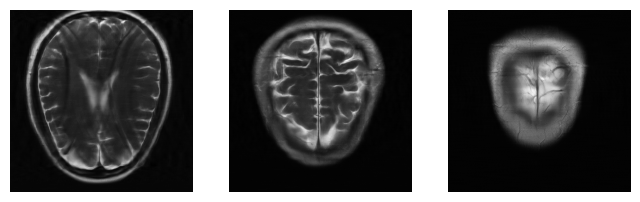

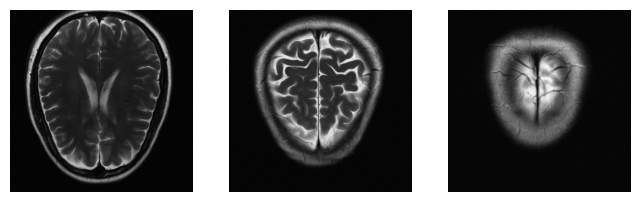

In [6]:
from typing import Optional
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# Volume-wise PNR ans SSIM calculation
def vol_avg_measures(
    gt: np.ndarray, pred: np.ndarray, maxval: Optional[float] = None
) -> np.ndarray:
    
    """Computes volume-wise average following measures:
    Normalized Mean Square Error (NMSE),
     Peak Signal to Noise Ratio (PSNR), Structural Similarity Index Metric (SSIM)"""
    
    if not gt.ndim == 3:
        raise ValueError("Unexpected number of dimensions in ground truth.")
    if not gt.ndim == pred.ndim:
        raise ValueError("Ground truth dimensions does not match pred.")
    
    maxval = gt.max() if maxval is None else maxval

    nmse_mes = np.array([0])
    ssim_mes = np.array([0])
    psnr_mes = np.array([0])

    for slice_num in range(gt.shape[0]):
        
        nmse_mes = nmse_mes + nmse(
            gt[slice_num], pred[slice_num]
        )
        
        psnr_mes = psnr_mes + psnr(
            gt[slice_num], pred[slice_num], data_range=maxval
        )

        ssim_mes = ssim_mes + ssim(
            gt[slice_num], pred[slice_num], data_range=maxval
        )

    return nmse_mes / gt.shape[0], psnr_mes / gt.shape[0], ssim_mes / gt.shape[0]

def nmse(gt: np.ndarray, pred: np.ndarray) -> np.ndarray:
    """Compute Normalized Mean Squared Error (NMSE)"""
    return np.array(np.linalg.norm(gt - pred) ** 2 / np.linalg.norm(gt) ** 2) 

#%% --------------- Model Inference Starts HERE-------------
# Define file paths
model_path = '/mnt/sdb/susant/ProjBased_CascadeUNet/ProjCascadeUNet_savedModels/Acc8_ProjCasUnet_b8/CascadeUNet_Acc8_best_l1b8_subset.pth'
input_file = '/mnt/sdb/susant/file_brain_AXT2_200_6002116.h5'

# Load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Unet_Model(num_chans=32, num_pools=4, drop_prob=0.0).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# Load the volume to be reconstructed
with h5py.File(input_file, 'r') as h5test:
    h5attrs = dict(h5test.attrs)
    h5maxval = h5attrs['max']
    h5acquisition = h5attrs['acquisition']

    # Load k-space and ground truth data as NumPy arrays
    target = np.array(h5test['reconstruction_rss'])  # Explicitly convert to NumPy array


num_slices = target.shape[0]
gt_imgs = []
recon_imgs = []

for i in range(num_slices):
    target1 = T.center_crop(target[i], (320,320))
    image = T.to_tensor(target1.astype(complex))
    gt_imgs.append(target1)
    kspace = T.fft2c_new(image)

    # Preprocessing
    mask_func = subsample.RandomMaskFunc(center_fractions=[0.04], accelerations=[8])
    seed = True
    masked_kspace, mask,_ = T1.apply_mask(kspace, mask_func, seed)
    inv_mask = (1 - mask)
    mean, std = torch.mean(masked_kspace), torch.std(masked_kspace)

    # Initialize input 
    zf = T.ifft2c_new(masked_kspace)  # Convert masked k-space to image domain
    dirty = T.complex_abs(zf).type(torch.FloatTensor)  # Convert to magnitude image
    dirty, mean, std = T.normalize_instance(dirty, eps=1e-11)
    dirty = dirty.unsqueeze(0)

    # Model inference
    with torch.no_grad():
        output_norm = model.updatedcascad(
            dirty.to(device),
            mean.to(device),
            std.to(device),
            masked_kspace.to(device),
            inv_mask.to(device)
        )

    # Post-processing
    output = output_norm * std + mean
    output_np = output.squeeze().cpu().numpy()  # Convert output to NumPy array
    recon_imgs.append(output_np)
    

gt_imgs_np = np.asarray(gt_imgs, dtype=np.float32)
recon_imgs_np = np.asarray(recon_imgs, dtype=np.float32)
np.save('PBCUnet_Acc8_brain.npy', recon_imgs_np)

# Calculate Quantitative Indices Avg. volume-wise
avg_nmse, avg_psnr, avg_ssim = vol_avg_measures(gt_imgs_np, recon_imgs_np, h5maxval)

print(f'Acquistion: {str(h5acquisition)}, Average NMSE: {avg_nmse[0]:.4f}')
print(f'Acquistion: {str(h5acquisition)}, Average PSNR: {avg_psnr[0]:.4f}')
print(f'Acquistion: {str(h5acquisition)}, Average SSIM: {avg_ssim[0]:.4f}')


show_slices(recon_imgs_np, [4, 10, 13], cmap='gray')
show_slices(gt_imgs_np, [4, 10, 13], cmap='gray')

**Single Slice: Inference**

Acquisition: CORPD_FBK, Slice 18, NMSE: 0.0014
Acquisition: CORPD_FBK, Slice 18, PSNR: 44.4850
Acquisition: CORPD_FBK, Slice 18, SSIM: 0.9740


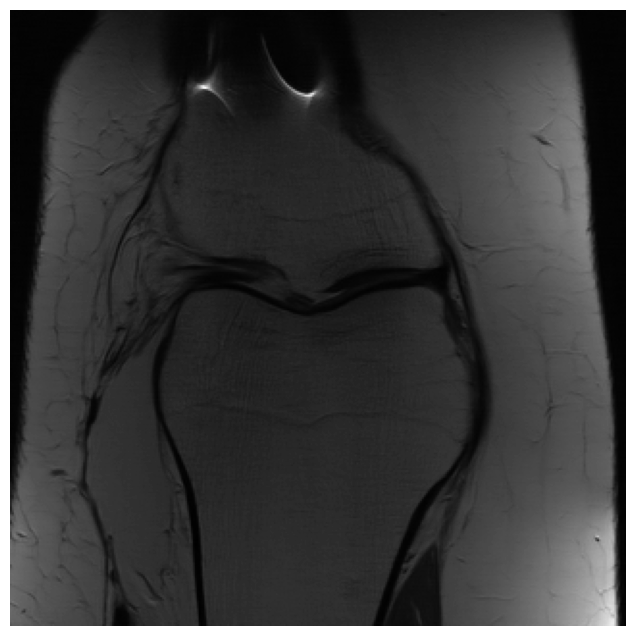

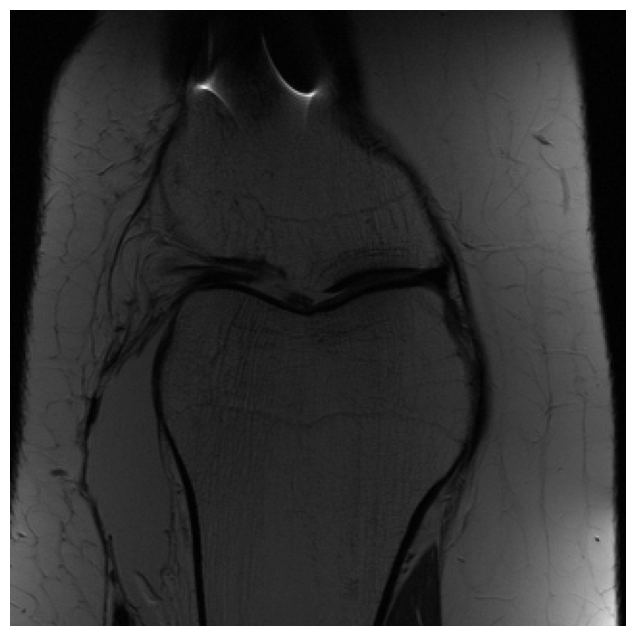

In [22]:
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr


# ---------------------- Metrics Calculation ----------------------
def nmse(gt: np.ndarray, pred: np.ndarray) -> float:
    """Compute Normalized Mean Squared Error (NMSE)"""
    return np.linalg.norm(gt - pred) ** 2 / np.linalg.norm(gt) ** 2

# ---------------------- Model Inference ----------------------
# Define file paths
model_path = "/mnt/sdb/susant/ProjBased_CascadeUNet/ProjCascadeUNet_savedModels/Acc4_ProjCasUNet_b8/CascadeUNet_Acc4_best_l1b1_subset.pth"
input_file = "/mnt/sdb/susant/knee_multicoil_val_subset/file1000052.h5"

# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Unet_Model(num_chans=32, num_pools=4, drop_prob=0.0).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# Load the volume to be reconstructed
with h5py.File(input_file, "r") as h5test:
    h5attrs = dict(h5test.attrs)
    h5maxval = h5attrs.get("max", 1.0)  # Default max value if missing
    h5acquisition = h5attrs.get("acquisition", "Unknown")
    target = np.array(h5test["reconstruction_rss"], dtype=np.float32)  # Convert to NumPy

# Select only the first slice
i = 18
image = T.to_tensor(target[i].astype(complex))
kspace = T.fft2c_new(image)

# Preprocessing
mask_func = subsample.RandomMaskFunc(center_fractions=[0.08], accelerations=[4])
seed = True
masked_kspace, mask, _ = T1.apply_mask(kspace, mask_func, seed)
inv_mask = (1 - mask)
mean, std = torch.mean(masked_kspace), torch.std(masked_kspace)

# Initialize input
zf = T.ifft2c_new(masked_kspace)  # Convert masked k-space to image domain
dirty = T.complex_abs(zf).type(torch.FloatTensor)  # Convert to magnitude image
dirty, mean, std = T.normalize_instance(dirty, eps=1e-11)
dirty = dirty.unsqueeze(0)  # Add batch dimension

# Model inference
with torch.no_grad():
    output_norm = model.updatedcascad(
        dirty.to(device),
        mean.to(device),
        std.to(device),
        masked_kspace.to(device),
        inv_mask.to(device)
    )

# Post-processing
output = output_norm * std + mean
recon_slice = output.squeeze().cpu().numpy()  # Convert output to NumPy array
target_slice = target[i]  # Ground truth slice

# Calculate Quantitative Indices
slice_nmse = nmse(target_slice, recon_slice)
slice_psnr = psnr(target_slice, recon_slice, data_range=h5maxval)
slice_ssim = ssim(target_slice, recon_slice, data_range=h5maxval)

# Print results for the single slice
print(f'Acquisition: {h5acquisition}, Slice {i}, NMSE: {slice_nmse:.4f}')
print(f'Acquisition: {h5acquisition}, Slice {i}, PSNR: {slice_psnr:.4f}')
print(f'Acquisition: {h5acquisition}, Slice {i}, SSIM: {slice_ssim:.4f}')

# Visualize the selected slice
show_slices(np.expand_dims(recon_slice, axis=0), [0], cmap="gray")
show_slices(np.expand_dims(target_slice, axis=0), [0], cmap="gray")


**Folder and all volumes**

In [ ]:
import os
import h5py
import numpy as np
import torch
import time
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
from typing import Optional

# Define source folder path and model path
folderpath_val = '/mnt/sdb/susant/knee_multicoil_val_subset'
model_path = '/mnt/sdb/susant/ProjBased_CascadeUNet/ProjCascadeUNet_savedModels/Acc8_ProjCasUnet_b8/CascadeUNet_Acc8_best_l1b8_subset.pth'

# Initialize lists for CORPD and CORPDFS measures
corpd_measures = []
corpdfs_measures = []

# Load model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
model = Unet_Model(num_chans=32, num_pools=4, drop_prob=0.0).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# NMSE function
def nmse(gt: np.ndarray, pred: np.ndarray) -> np.ndarray:
    return np.array(np.linalg.norm(gt - pred) ** 2 / np.linalg.norm(gt) ** 2)

# Volume-wise metrics
def vol_avg_measures(gt: np.ndarray, pred: np.ndarray, maxval: Optional[float] = None):
    maxval = gt.max() if maxval is None else maxval
    psnr_vals, ssim_vals = [], []

    for slice_num in range(gt.shape[0]):
        psnr_vals.append(psnr(gt[slice_num], pred[slice_num], data_range=maxval))
        ssim_vals.append(ssim(gt[slice_num], pred[slice_num], data_range=maxval))
    
    nmse_val = nmse(gt, pred)
    return np.mean(nmse_val), np.mean(psnr_vals), np.mean(ssim_vals)

# Main loop over files
for filename in os.listdir(folderpath_val):
    if filename.endswith('.h5'):
        filepath = os.path.join(folderpath_val, filename)

        with h5py.File(filepath, 'r') as h5test:
            h5attrs = dict(h5test.attrs)
            h5maxval = h5attrs['max']
            h5acquisition = h5attrs['acquisition']

            if h5acquisition not in ['CORPD_FBK', 'CORPDFS_FBK']:
                continue

            target = np.array(h5test['reconstruction_rss'])
            num_slices = target.shape[0]
            gt_imgs, recon_imgs = [], []
            slice_times = []

            for i in range(num_slices):
                # Preprocessing
                image = T.to_tensor(target[i].astype(complex))
                gt_imgs.append(target[i])
                kspace = T.fft2c_new(image)

                mask_func = subsample.RandomMaskFunc(center_fractions=[0.08], accelerations=[4])
                masked_kspace, mask, _ = T1.apply_mask(kspace, mask_func, seed=True)
                inv_mask = (1 - mask)

                mean, std = torch.mean(masked_kspace), torch.std(masked_kspace)
                zf = T.ifft2c_new(masked_kspace)
                dirty = T.complex_abs(zf).type(torch.FloatTensor)
                dirty, mean, std = T.normalize_instance(dirty, eps=1e-11)
                dirty = dirty.unsqueeze(0)

                # Inference timing
                start_time = time.time()
                with torch.no_grad():
                    output_norm = model.updatedcascad(
                        dirty.to(device), mean.to(device), std.to(device),
                        masked_kspace.to(device), inv_mask.to(device)
                    )
                end_time = time.time()
                slice_times.append(end_time - start_time)

                # Postprocessing
                output = output_norm * std + mean
                recon_imgs.append(output.squeeze().cpu().numpy())

            # Compute metrics
            gt_imgs_np = np.asarray(gt_imgs, dtype=np.float32)
            recon_imgs_np = np.asarray(recon_imgs, dtype=np.float32)
            avg_nmse, avg_psnr, avg_ssim = vol_avg_measures(gt_imgs_np, recon_imgs_np, h5maxval)
            time_mean, time_std = round(np.mean(slice_times), 4), round(np.std(slice_times), 4)

            result = (filename, round(avg_nmse,4), round(avg_psnr,4), round(avg_ssim,4), time_mean, time_std)

            if h5acquisition == 'CORPD_FBK':
                corpd_measures.append(result)
            elif h5acquisition == 'CORPDFS_FBK':
                corpdfs_measures.append(result)

# Print results
print("CORPD Measures:")
for item in corpd_measures:
    print(item)

print("\nCORPDFS Measures:")
for item in corpdfs_measures:
    print(item)


cuda
CORPD Measures:
('file1000350.h5', 0.0016, 41.0537, 0.9577, 0.0476, 0.0034)
('file1001715.h5', 0.0048, 38.4713, 0.9056, 0.0488, 0.0034)
('file1000328.h5', 0.0024, 40.036, 0.9475, 0.046, 0.0016)
('file1000389.h5', 0.0027, 39.873, 0.9536, 0.0452, 0.0011)
('file1000759.h5', 0.0033, 39.8907, 0.9528, 0.0447, 0.0006)
('file1000432.h5', 0.0043, 38.6994, 0.9373, 0.0447, 0.0009)
('file1001893.h5', 0.0023, 39.9324, 0.9514, 0.0458, 0.0005)
('file1001126.h5', 0.003, 42.0332, 0.9622, 0.0456, 0.0006)
('file1000283.h5', 0.0037, 38.877, 0.9362, 0.0461, 0.0005)
('file1001122.h5', 0.0049, 40.159, 0.9437, 0.0463, 0.0005)
('file1002382.h5', 0.0023, 41.3131, 0.963, 0.0457, 0.0005)
('file1000817.h5', 0.0025, 42.8779, 0.9666, 0.0501, 0.0022)
('file1000153.h5', 0.0036, 37.5026, 0.9245, 0.0463, 0.0013)
('file1002526.h5', 0.0019, 42.8662, 0.9659, 0.0465, 0.0011)
('file1001930.h5', 0.0024, 39.4458, 0.9496, 0.0451, 0.0004)
('file1001650.h5', 0.0032, 44.2994, 0.9733, 0.0451, 0.0005)
('file1001170.h5', 0.0034,

: 

In [13]:
# Write to a CSV file
# Save items to a CSV file
import csv
with open("PBcasUNet_corpdfs_Acc84.csv", mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerows(corpdfs_measures)  # Write all rows at once

print("Items saved to output.csv.")

Items saved to output.csv.
